# 01. ROSE and LROM for a Single Scattering Wavefunction

This notebook introduces the
`lrom` package. Introducing how to initialize and use the package, where we compare high-fidelity solutions of the nuclear
scattering equation with ROSE/RBM and LROM approximations for the $l=0$ channel of $^{40}$Ca(n,n) at 14.1 MeV. Treating the Least Squares (LS) as the benchmark.



Comparison between benchmark and LROM examples in 2 sections:

- Section 1: `vv_emulator`: `ws_1`, varying Vv pipeline, benchmarking LROM to ROSE and exact solution
- Section 2: `ws3_emulator`: `ws_3`, varying Vv/Rv/av pipeline, benchmarking LROM potential predictors


In [1]:
# Numerical, interpolation, and plotting dependencies used below.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator

# Resolve the active checkout whether execution starts at the root or notebooks folder.
ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Discard stale interactive imports before loading this checkout.
for name in list(sys.modules):
    if name in ("lrom", "lrom_legacy") or name.startswith(("lrom.", "lrom_legacy.")):
        del sys.modules[name]

import scipy.special

if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # Legacy sph_harm uses (azimuthal, polar); sph_harm_y uses (polar, azimuthal).
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(
        n, m, phi, theta
    )

plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.25})


In [2]:
# Import ROSE only for benchmarking; public LROM v1.2 supplies the studied emulator.
import rose
import lrom
import benchmark_helper

print("LROM package:", lrom.__version__)


LROM package: 1.2.0


# Section 1. Parameter Varying Vv


#### LROM Pipeline for producing solutions for a Varying Vv
The first emulator (object) has a testing interval wider than its training interval. With fixed
$R_v$ and $a_v$ values from the Koning-Delaroche global optical potential. Target/projectile system is at 14.1 MeV laboratory
energy; where only $V_v$ will vary.

In this example we are using the radial scattering equation, in which the high fidelity method would use a differential method for evaluating the radual solution.

$$


\left[
-\frac{d^2}{ds^2}
+\frac{2\mu V(r;\alpha)}{\hbar^2}
+\frac{\ell(\ell+1)}{r^2}
\frac{2\eta k}{r}-k^2
\right]
\phi_\alpha(r)
=0
\qquad
r=\frac{s}{k}.
$$


with woods saxon 
$$
V_{\mathrm{WS}}(r;V_v)
=
-\frac{V_v}
{1+\exp\!\left(\dfrac{r-R_v}{a_v}\right)}.
$$

LROM equation for single parameter

$$
\left(
\mathbf{I}
+
\sum_{j=1}^{N_p} p_j\,\mathbf{M}_j
\right)
\mathbf{a}(\mathbf{p})
=
\sum_{j=1}^{N_p} p_j\,\mathbf{b}_j,
$$

$$
\phi_{\mathrm{LROM}}(r;\mathbf{p})
=
\phi_0(r)
+
\sum_{i=1}^{N_\phi}
a_i(\mathbf{p})\,\psi_i(r).
$$

In [3]:
# Shared reduced basis and plotting conventions.
BASIS_SIZE = 4
DISPLAY_ERROR_FLOOR = 1e-11
METHOD_COLORS = {"ls": "blue", "lrom": "#E6AB02", "rose": "red"}
BLUE_PINK_CMAP = LinearSegmentedColormap.from_list(
    "blue_to_pink", ("#1f4aa8", "#6f78d1", "#c468c5", "#f05a9d")
)

# The first system varies only the real Woods-Saxon depth in the ell=0 channel.
vv_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_1",
)

# Testing deliberately extends beyond the training interval to expose extrapolation.
vv_center = dict(vv_emulator.central_parameters)
Vv0 = vv_center["Vv"]
vv_training_ranges = {"Vv": (0.90 * Vv0, 1.10 * Vv0)}
vv_testing_ranges = {"Vv": (0.65 * Vv0, 1.35 * Vv0)}

# Generate high-fidelity radial solutions on a physical-fm mesh.
vv_emulator.sampling(
    training_ranges=vv_training_ranges,
    testing_ranges=vv_testing_ranges,
    training_size=35,
    testing_size=41,
    mesh_size=800,
    strategy="linspace",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)

# One scalar feature produces one learned reduced operator matrix.
vv_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=1,
)


#### ROSE/LS Solutions

We run the ROSE pipeline for producing emulated solutions for the testing range, which uses the galerkin method for producing coefficients. Along with this, we produce emulated solutions using the exact least squares method for producing coefficients.

In [4]:
# Build ROSE and exact least-squares results from the identical sampled wavefunctions.
vv_samples = vv_emulator.samples
vv_fom_train = vv_samples.training_wavefunctions[0]
vv_fom_test = vv_samples.testing_wavefunctions[0]

vv_benchmark = benchmark_helper.WavefunctionBenchmark(
    emulator=vv_emulator,
    center=vv_center,
)
vv_comparison = vv_benchmark.run(
    basis_size=BASIS_SIZE,
    eim_basis_size=8,
    include_training_wavefunctions=False,
)

# LS coordinates are projections into the LROM basis and form the oracle baseline.
vv_ls_train_coefficients = vv_comparison.ls.training_coefficients
vv_ls_coefficients = vv_comparison.ls.testing_coefficients
vv_ls_train_wavefunctions = vv_comparison.ls.training_wavefunctions
vv_ls_wavefunctions = vv_comparison.ls.testing_wavefunctions
vv_ls_relative_l2 = lrom.relative_l2(
    prediction=vv_ls_wavefunctions,
    reference=vv_fom_test,
)

for key, value in {
    "central parameters": dict(vv_emulator.central_parameters),
    "fixed Rv [fm]": vv_center["Rv"],
    "fixed av [fm]": vv_center["av"],
    "training wavefunctions": vv_fom_train.shape,
    "testing wavefunctions": vv_fom_test.shape,
}.items():
    print(f"{key}: {value}")

# ROSE uses its own free-reference basis but the same physical sample rows.
vv_rose = vv_comparison.rose
vv_train_rows = vv_rose.training_rows
vv_test_rows = vv_rose.testing_rows
vv_rose_basis = vv_rose.basis
vv_rose_train_coefficients = vv_rose.training_coefficients
vv_rose_coefficients = vv_rose.testing_coefficients
vv_rose_wavefunctions = vv_rose.testing_wavefunctions


central parameters: {'Vv': 48.822175142383706, 'Rv': 4.053875273743491, 'av': 0.671852}
fixed Rv [fm]: 4.053875273743491
fixed av [fm]: 0.671852
training wavefunctions: (35, 800)
testing wavefunctions: (41, 800)


### Training set

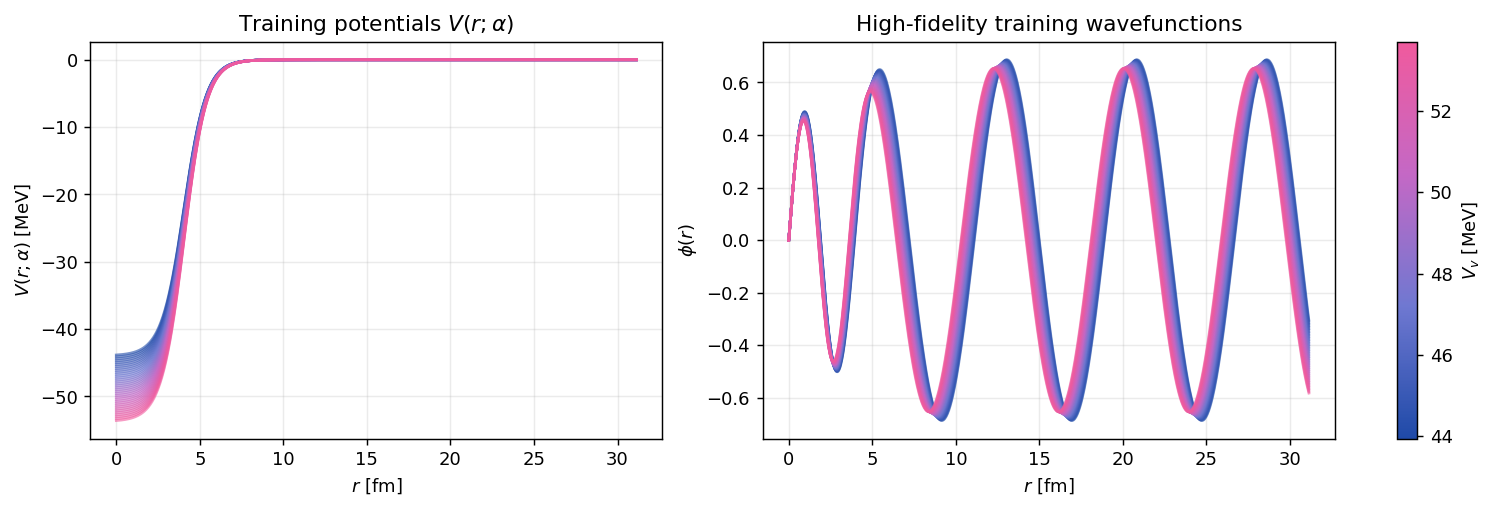

In [5]:
# Plot the physical potentials and their high-fidelity radial solutions.
r = vv_emulator.mesh.radius
vv_values = vv_emulator.samples.design.training.values[:, 0]
norm = plt.Normalize(vv_values.min(), vv_values.max())

fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.8), layout="constrained")
data = [
    (axes[0], vv_emulator.samples.training_potentials, r"$V(r;\alpha)$ [MeV]", r"Training potentials $V(r;\alpha)$"),
    (axes[1], vv_emulator.samples.training_wavefunctions[0], r"$\phi(r)$", "High-fidelity training wavefunctions"),
]
for ax, curves, ylabel, title in data:
    for value, curve in zip(vv_values, curves):
        ax.plot(r, curve.real, color=BLUE_PINK_CMAP(norm(value)), alpha=0.60)
    ax.set(xlabel=r"$r$ [fm]", ylabel=ylabel, title=title)

fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=BLUE_PINK_CMAP), ax=axes, label=r"$V_v$ [MeV]")
plt.show()


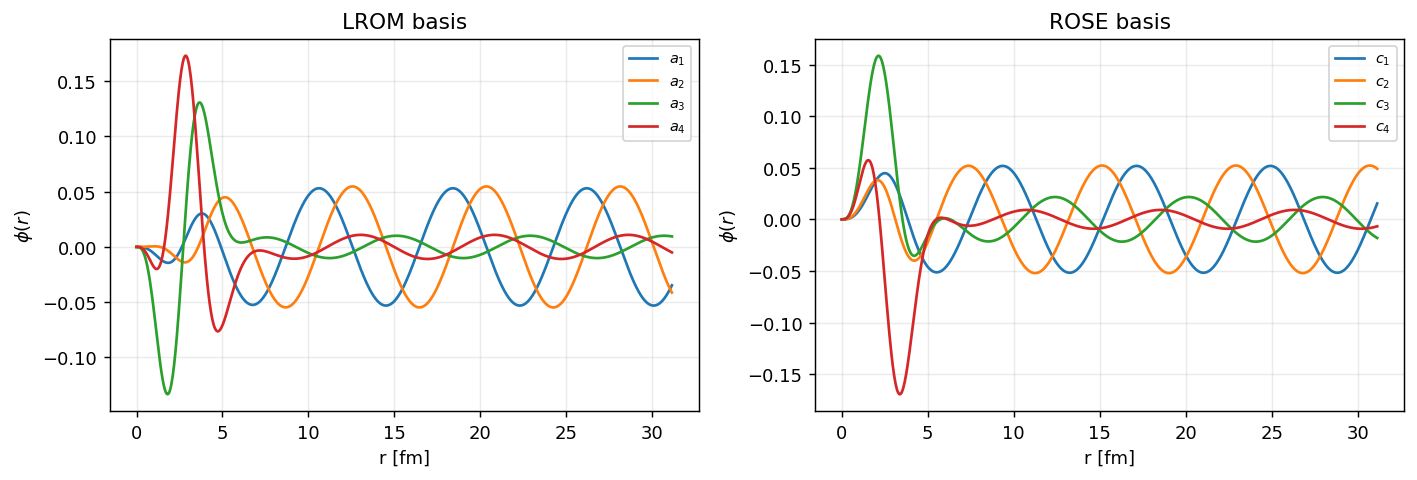

In [6]:
# Compare the LROM central-reference basis with the ROSE free-reference basis.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
basis_panels = [(vv_emulator.basis[0], "LROM", "a"), (vv_rose_basis, "ROSE", "c")]

for ax, (basis, name, symbol) in zip(axes, basis_panels):
    for basis_index in range(BASIS_SIZE):
        ax.plot(
            r,
            np.real(basis.vectors[:, basis_index]),
            label=fr"${symbol}_{{{basis_index + 1}}}$",
        )
    ax.set(xlabel="r [fm]", ylabel=r"$\phi(r)$", title=f"{name} basis")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


### Evaluated Coefficients (for training and testing), that can be applied to the reduced basis

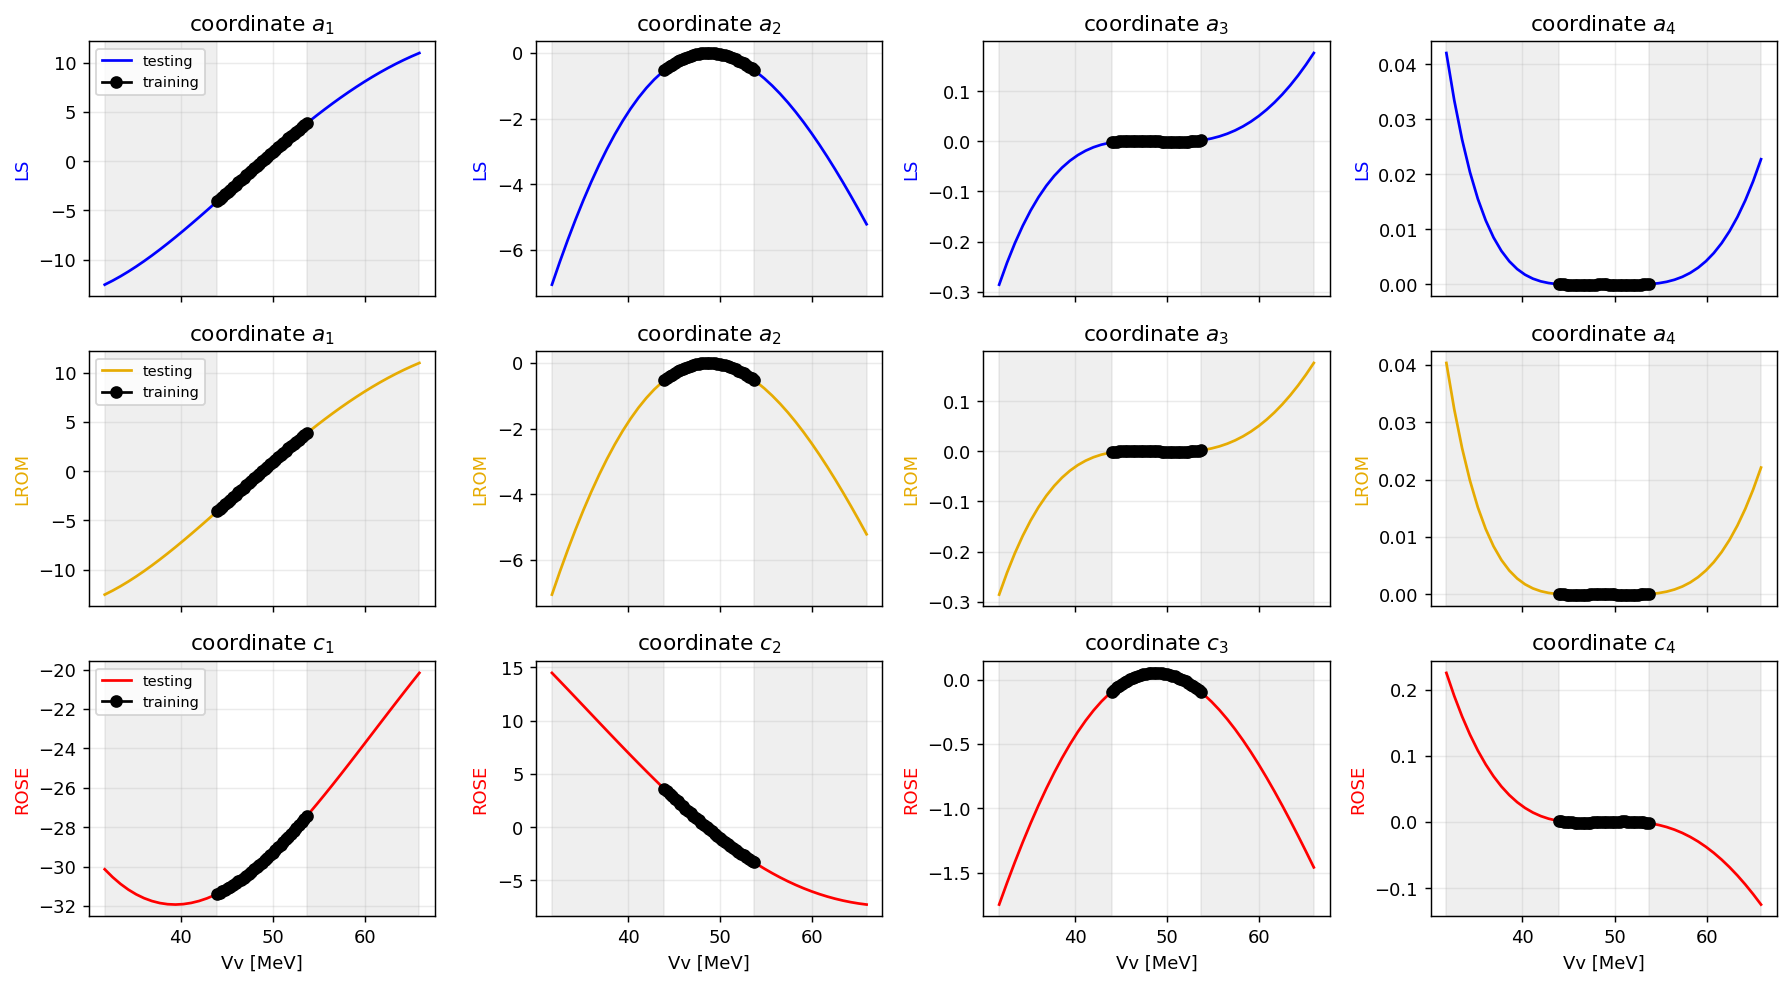

In [7]:
vv_train = vv_train_rows[:, 0]
vv_test = vv_test_rows[:, 0]
mask = ~np.isclose(vv_test, Vv0, rtol=0.0, atol=1e-12)
vv_plot_mask = mask
lo, hi = vv_training_ranges["Vv"]

vv_coordinate_data = [
    ("LS", vv_ls_train_coefficients, vv_ls_coefficients, "a", METHOD_COLORS["ls"]),
    ("LROM",
     np.asarray(vv_emulator.training_results.coefficients["lrom"][0]),
     np.asarray(vv_emulator.testing_results.coefficients["lrom"][0]),
     "a", METHOD_COLORS["lrom"]),
    ("ROSE", vv_rose_train_coefficients, vv_rose_coefficients, "c", METHOD_COLORS["rose"]),
]

fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14, 8), sharex="col")
last = len(vv_coordinate_data) - 1

for i, (method, train_c, test_c, sym, color) in enumerate(vv_coordinate_data):
    for j in range(BASIS_SIZE):
        ax = axes[i, j]
        first = j == 0
        ax.plot(vv_test[mask], test_c[mask, j].real, color=color,
                label="testing" if first else None)
        ax.plot(vv_train, train_c[:, j].real, marker="o", color="black",
                label="training" if first else None)
        ax.axvspan(vv_test.min(), lo, color="gray", alpha=0.12)
        ax.axvspan(hi, vv_test.max(), color="gray", alpha=0.12)
        ax.set_title(fr"coordinate ${sym}_{{{j+1}}}$")
        ax.set_ylabel(method, color=color)
        if i == last:
            ax.set_xlabel("Vv [MeV]")
    axes[i, 0].legend(fontsize=8)

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### Varying Vv emulation results

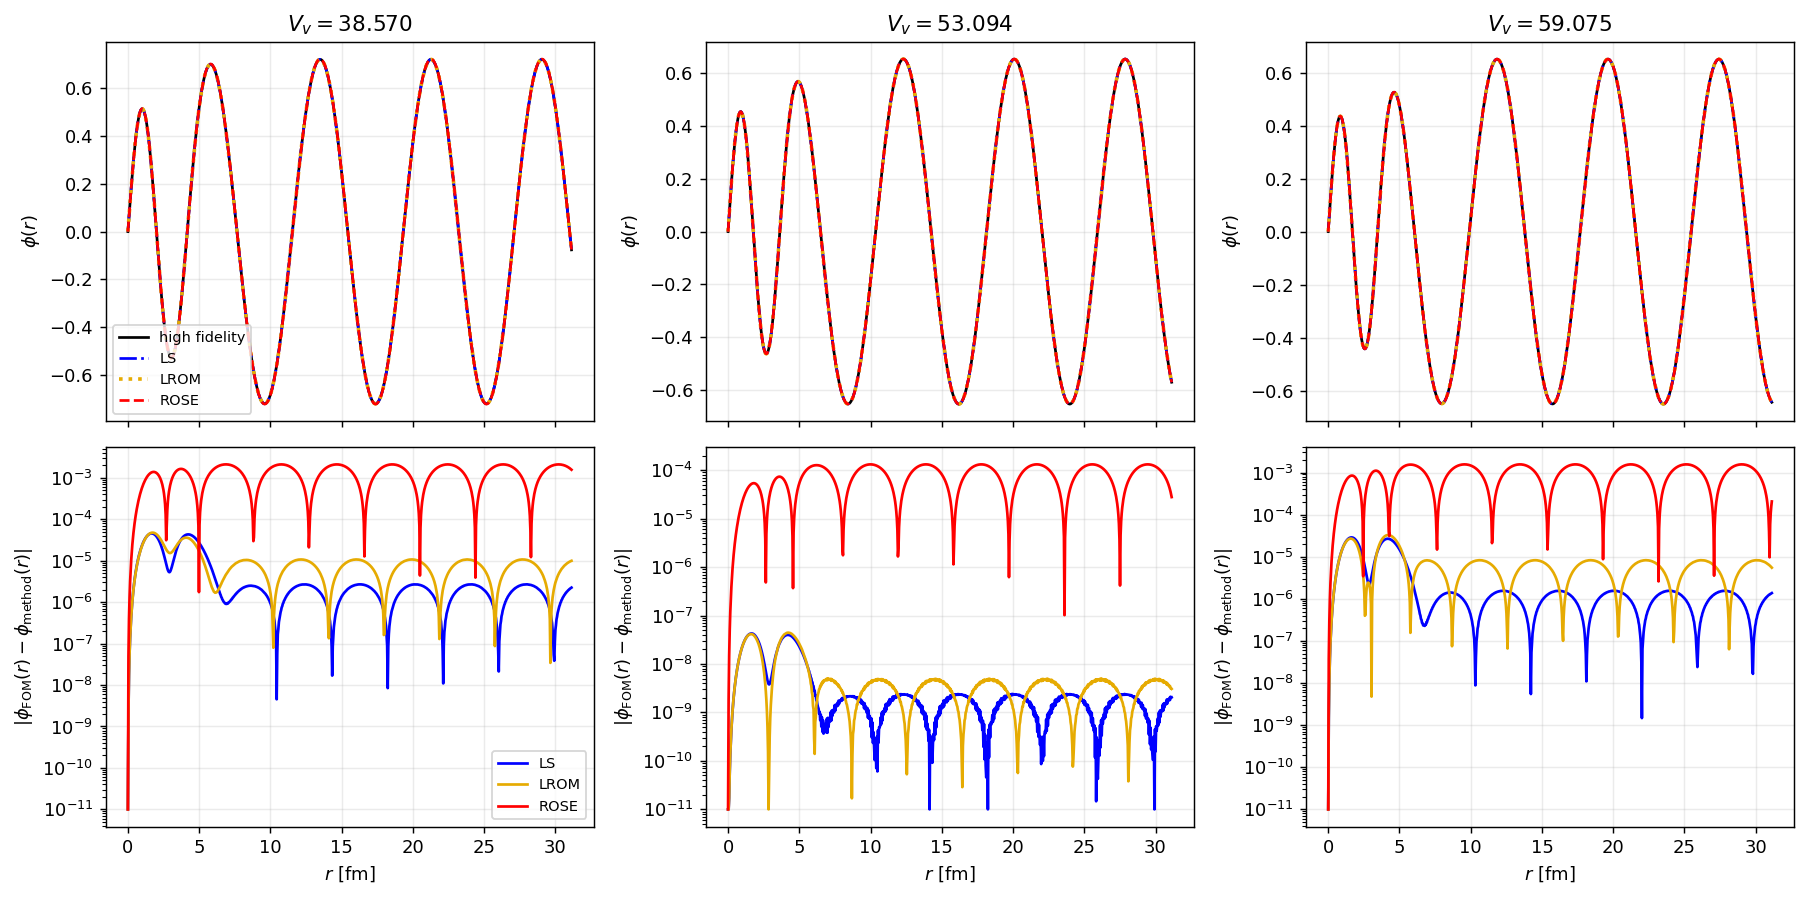

In [8]:
# Eligible cases: away from the central reference, and not overlapping training points.
vv_half_range = 0.5 * (vv_testing_ranges["Vv"][1] - vv_testing_ranges["Vv"][0])
vv_normalized_distance = np.abs(vv_test - Vv0) / vv_half_range
vv_training_overlap = np.any(
    np.isclose(vv_test[:, None], vv_train[None, :], rtol=0.0, atol=1e-12),
    axis=1,
)
vv_eligible = np.flatnonzero((vv_normalized_distance >= 0.25) & ~vv_training_overlap)
assert len(vv_eligible) >= 3

# Pick three eligible cases spread across the Vv range.
vv_sorted = vv_eligible[np.argsort(vv_test[vv_eligible])]
vv_positions = np.rint(np.array([0.25, 0.50, 0.75]) * (len(vv_sorted) - 1)).astype(int)
vv_selected_indices = vv_sorted[vv_positions]
assert len(np.unique(vv_selected_indices)) == 3

vv_case_ids = np.asarray(vv_emulator.samples.design.testing.case_ids)

fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0), sharex="col")
for column, selected_index in enumerate(vv_selected_indices):
    vv_case = vv_emulator.testing_case(case_id=vv_case_ids[selected_index])
    reference = vv_case.high_fidelity[0]
    methods = (
        ("LS", vv_ls_wavefunctions[selected_index], "ls", "-.", None),
        ("LROM", vv_case.lrom[0], "lrom", ":", 2),
        ("ROSE", vv_rose_wavefunctions[selected_index], "rose", "--", None),
    )

    axes[0, column].plot(vv_case.radius, np.real(reference), color="black", label="high fidelity")
    for name, prediction, key, style, width in methods:
        axes[0, column].plot(
            vv_case.radius, np.real(prediction), style,
            color=METHOD_COLORS[key], linewidth=width, label=name,
        )
        axes[1, column].plot(
            vv_case.radius,
            np.maximum(np.abs(reference - prediction), DISPLAY_ERROR_FLOOR),
            color=METHOD_COLORS[key], label=name,
        )
    axes[0, column].set(ylabel=r"$\phi(r)$", title=fr"$V_v={vv_test[selected_index]:.3f}$")
    axes[1, column].set(xlabel=r"$r$ [fm]", ylabel=r"$|\phi_{\mathrm{FOM}}(r)-\phi_{\mathrm{method}}(r)|$")
    axes[1, column].set_yscale("log")

axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

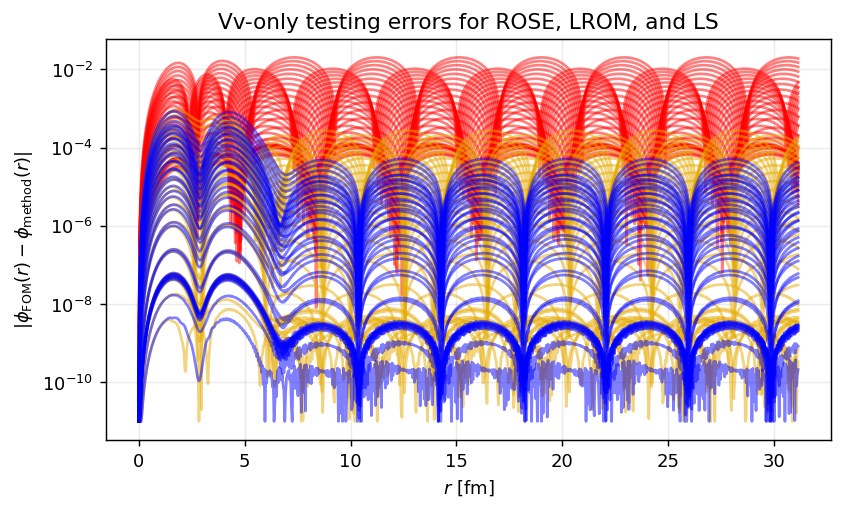

In [9]:
# Overlay every held-out absolute-difference curve for the three methods.
vv_errors = dict(vv_emulator.testing_errors[0])
vv_errors["ls"] = np.abs(vv_ls_wavefunctions - vv_fom_test)
vv_errors["rose"] = np.abs(vv_rose_wavefunctions - vv_fom_test)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method in ("rose", "lrom", "ls"):
    for error in vv_errors[method][vv_plot_mask]:
        ax.plot(
            r,
            np.maximum(error, DISPLAY_ERROR_FLOOR),
            color=METHOD_COLORS[method],
            alpha=0.5,
        )
ax.set_yscale("log")
ax.set_xlabel(r"$r$ [fm]")
ax.set_ylabel(r"$|\phi_{\mathrm{FOM}}(r)-\phi_{\mathrm{method}}(r)|$")
ax.set_title("Vv-only testing errors for ROSE, LROM, and LS")
plt.show()


## Section 2. Varied three parameters for the woods saxon potential

The second object varies Vv, Rv, and av. Potential predictors are selected values from the Woods-Saxon potential which are determined from the maxvol algorithim.

$$
V_{\mathrm{WS}}(r;V_v,R_v,a_v)
=
-\frac{V_v}
{1+\exp\!\left(\dfrac{r-R_v}{a_v}\right)}.
$$

The LROM equation:
$(I + \sum_{j=1}^{N_p}p_j(\alpha)M_j)a(\alpha)
= \sum_{j=1}^{N_p}p_j(\alpha)b_j$, where $\alpha=(V_v,R_v,a_v)$

All work for LROM is done within the first cell

In [10]:
# The second system varies depth, radius, and diffuseness together.
ws3_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_3",
)

# Testing again spans a wider cuboid than training.
ws3_center = dict(ws3_emulator.central_parameters)
ws3_training_ranges = {
    name: (0.90 * ws3_center[name], 1.10 * ws3_center[name])
    for name in ("Vv", "Rv", "av")
}
ws3_testing_ranges = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

ws3_emulator.sampling(
    training_ranges=ws3_training_ranges,
    testing_ranges=ws3_testing_ranges,
    training_size=70,
    testing_size=81,
    mesh_size=800,
    strategy="latin_hypercube",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)

# Three selected potential values produce three learned reduced operator matrices.
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=3,
)


### Predictor selection

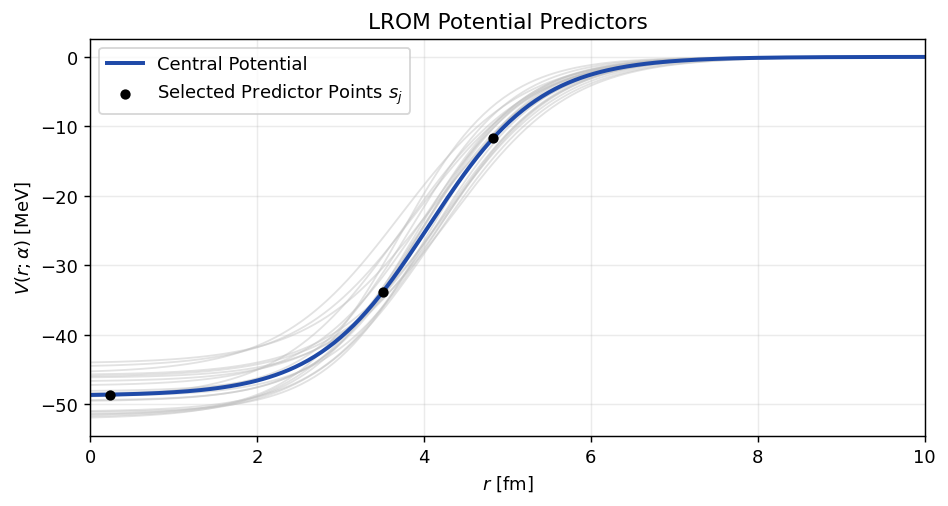

In [11]:
# Locate the selected potential features directly on the physical radius mesh.
r3 = ws3_emulator.mesh.radius
displayed_potentials = ws3_emulator.samples.training_potentials[:20]
central_potential = np.real(ws3_emulator.samples.central_potential)
selected_radii = ws3_emulator.predictors.selected_radii

fig, ax = plt.subplots(figsize=(7.4, 4.0))
for potential in displayed_potentials:
    ax.plot(
        r3, np.real(potential),
        color="0.75", alpha=0.45, linewidth=1.0,
    )
ax.plot(
    r3, central_potential,
    color="#1f4aa8", linewidth=2.2, label="Central Potential",
)
ax.scatter(
    selected_radii,
    np.interp(selected_radii, r3, central_potential),
    color="black", s=22, zorder=4,
    label=r"Selected Predictor Points $s_j$",
)
ax.set(
    xlabel=r"$r$ [fm]",
    ylabel=r"$V(r;\alpha)$ [MeV]",
    title="LROM Potential Predictors",
)
ax.legend()
ax.set_xlim(0.0, 10.0)
fig.tight_layout()
plt.show()


### Constructing LS and ROSE benchmark solutions for varying 3 parameters

In [12]:
# Reuse the sampled ws_3 solutions for matched LS and ROSE comparisons.
ws3_fom_train = ws3_emulator.samples.training_wavefunctions[0]
ws3_fom_test = ws3_emulator.samples.testing_wavefunctions[0]

ws3_benchmark = benchmark_helper.WavefunctionBenchmark(
    emulator=ws3_emulator,
    center=ws3_center,
)
ws3_comparison = ws3_benchmark.run(
    basis_size=BASIS_SIZE,
    eim_basis_size=8,
)

ws3_ls_train_coefficients = ws3_comparison.ls.training_coefficients
ws3_ls_coefficients = ws3_comparison.ls.testing_coefficients
ws3_ls_wf_train = ws3_comparison.ls.training_wavefunctions
ws3_ls_wf_test = ws3_comparison.ls.testing_wavefunctions
ws3_ls_rel_train = lrom.relative_l2(
    prediction=ws3_ls_wf_train,
    reference=ws3_fom_train,
)
ws3_ls_rel_test = lrom.relative_l2(
    prediction=ws3_ls_wf_test,
    reference=ws3_fom_test,
)

ws3_rose = ws3_comparison.rose
ws3_train_rows = ws3_rose.training_rows
ws3_test_rows = ws3_rose.testing_rows
ws3_rose_basis = ws3_rose.basis
ws3_rose_train_coefficients = ws3_rose.training_coefficients
ws3_rose_coefficients = ws3_rose.testing_coefficients
ws3_rose_wf_train = ws3_rose.training_wavefunctions
ws3_rose_wf_test = ws3_rose.testing_wavefunctions
ws3_rose_rel_train = (
    np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1)
    / np.linalg.norm(ws3_fom_train, axis=1)
)
ws3_rose_rel_test = (
    np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1)
    / np.linalg.norm(ws3_fom_test, axis=1)
)

print("potential operator radii [fm]:", ws3_emulator.predictors.selected_radii)


potential operator radii [fm]: [3.50667701 4.83142165 0.23377848]


Here we compare the reduced basis of ROSE and LROM for a varied 3 parameter woodsaxon

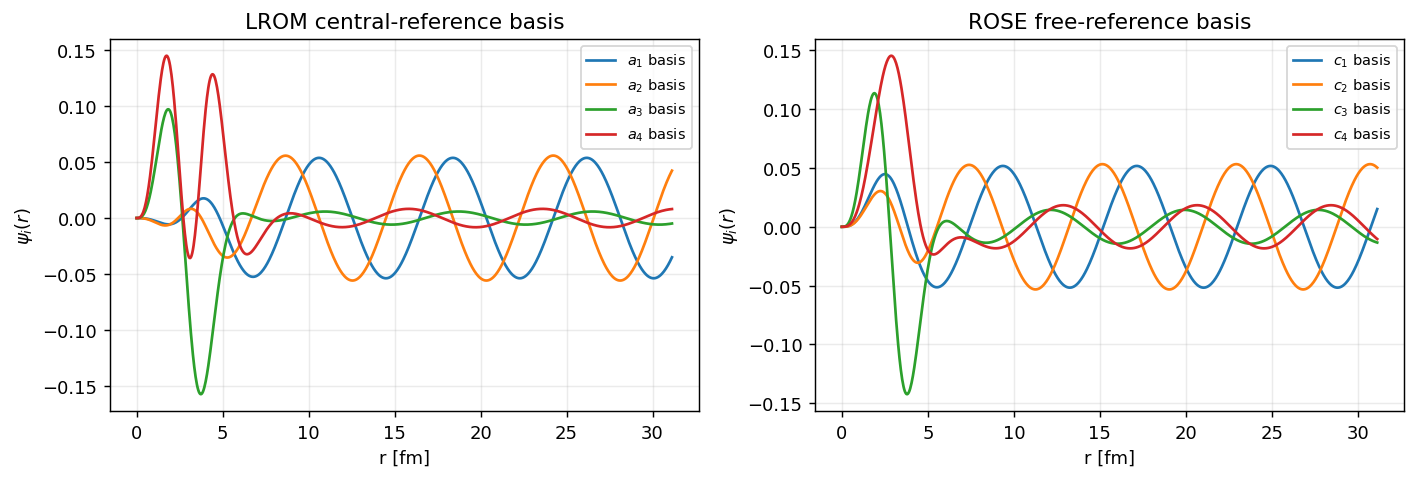

In [13]:
# Compare basis vectors built around different reference functions.
ws3_basis = ws3_emulator.basis[0]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))

for coordinate_index in range(BASIS_SIZE):
    axes[0].plot(
        r3,
        np.real(ws3_basis.vectors[:, coordinate_index]),
        label=fr"$a_{{{coordinate_index + 1}}}$ basis",
    )
    axes[1].plot(
        r3,
        np.real(ws3_rose_basis.vectors[:, coordinate_index]),
        label=fr"$c_{{{coordinate_index + 1}}}$ basis",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel=r"$\psi_i(r)$",
    title="LROM central-reference basis",
)
axes[1].set(
    xlabel="r [fm]",
    ylabel=r"$\psi_i(r)$",
    title="ROSE free-reference basis",
)
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### Coefficients from each method
interpreted by a 2d figure

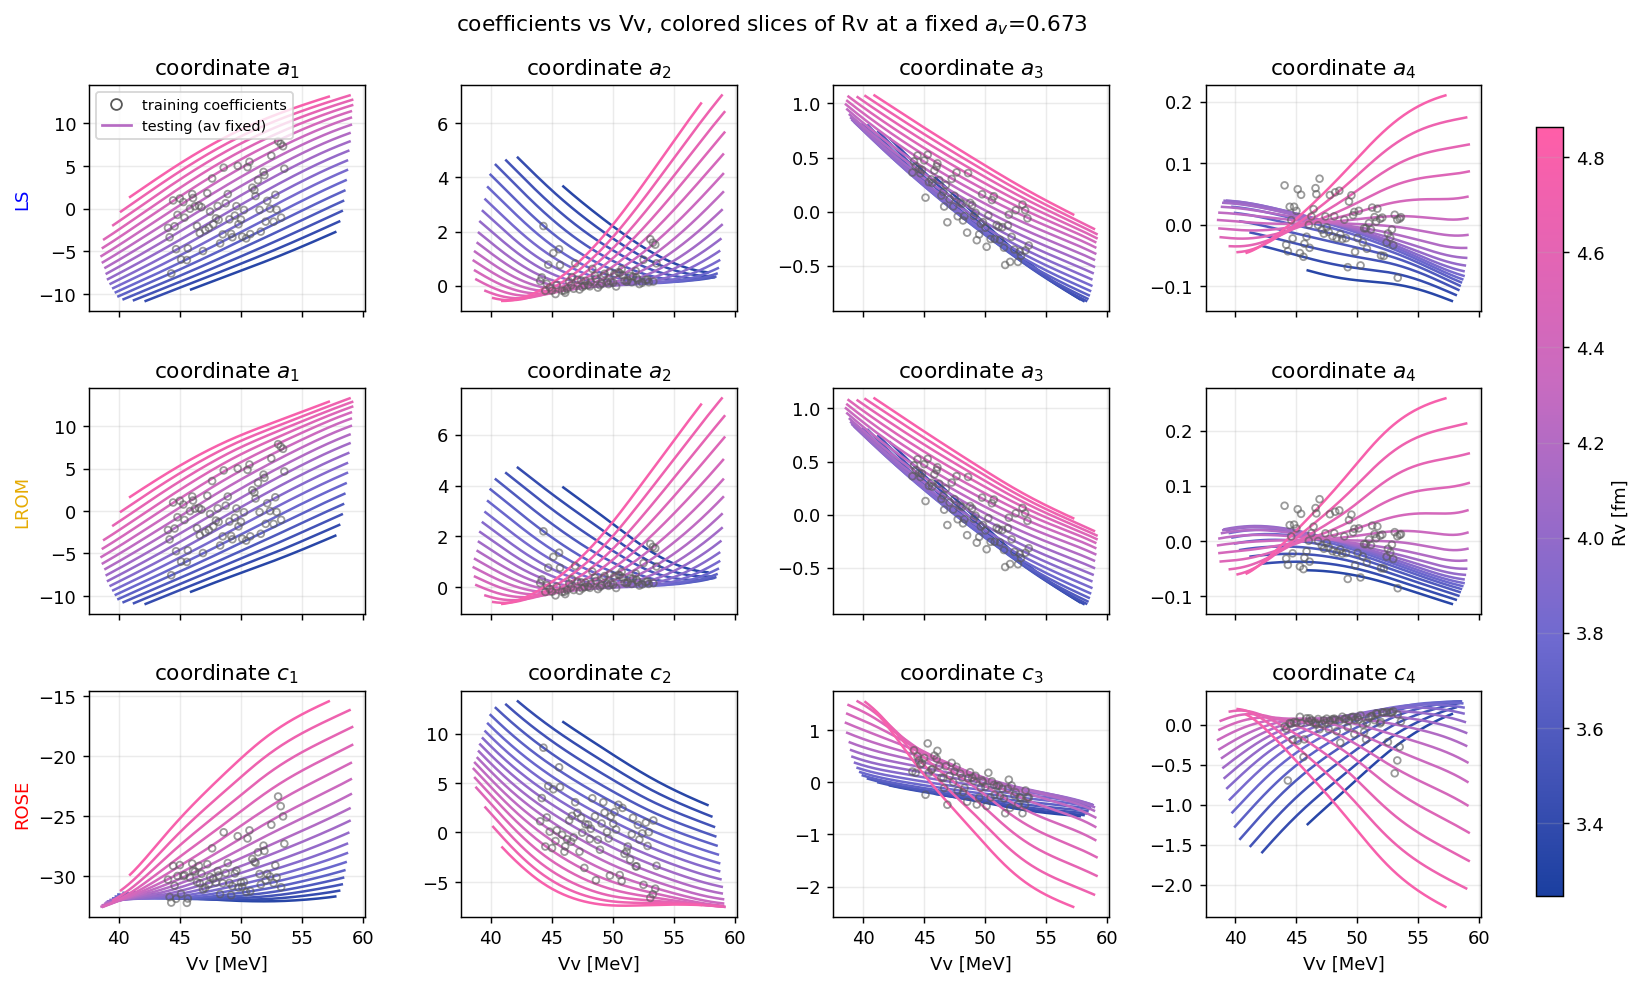

In [14]:
# organizing results into a dictionary
ws3_coordinate_data = {  # unchanged
    "LS":   {"training": ws3_ls_train_coefficients,
             "testing":  ws3_ls_coefficients,   "symbol": "a", "color": METHOD_COLORS["ls"]},
    "LROM": {"training": np.asarray(ws3_emulator.training_results.coefficients["lrom"][0]),
             "testing":  np.asarray(ws3_emulator.testing_results.coefficients["lrom"][0]),
             "symbol": "a", "color": METHOD_COLORS["lrom"]},
    "ROSE": {"training": ws3_rose_train_coefficients,
             "testing":  ws3_rose_coefficients, "symbol": "c", "color": METHOD_COLORS["rose"]},
}

# plotting routine
cmap = LinearSegmentedColormap.from_list("bluepink", ["#1b3fa0", "#6f6ad0", "#c86bc0", "#ff5ea8"])
params = ws3_test_rows[:, :3]                      # all columns: Vv, Rv, av
scale = params.std(0)                              # RBF needs comparable axis scales
av_fixed = np.median(ws3_test_rows[:, 2])

n_lines = 20
vv_grid = np.linspace(ws3_test_rows[:, 0].min(), ws3_test_rows[:, 0].max(), 200)
rv_lines = np.linspace(ws3_test_rows[:, 1].min(), ws3_test_rows[:, 1].max(), n_lines)
ws3_rv_norm = plt.Normalize(rv_lines.min(), rv_lines.max())

fig, axes = plt.subplots(3, BASIS_SIZE, figsize=(14.0, 8.0), sharex="col")
for row_index, (method, data) in enumerate(ws3_coordinate_data.items()):
    for coordinate_index in range(BASIS_SIZE):
        ax = axes[row_index, coordinate_index]
        values = np.real(data["testing"][:, coordinate_index])
        smooth = RBFInterpolator(params / scale, values,
                                 kernel="thin_plate_spline", smoothing=0.05)
        hull = LinearNDInterpolator(params, values)   

        for rv in rv_lines:
            query = np.column_stack([vv_grid, np.full_like(vv_grid, rv),
                                     np.full_like(vv_grid, av_fixed)])
            y = np.where(np.isnan(hull(query)), np.nan, smooth(query / scale))
            ax.plot(vv_grid, y, color=cmap(ws3_rv_norm(rv)), linewidth=1.4)#,marker='s',markevery=25,markersize=2.3)

        ax.scatter(ws3_train_rows[:, 0], np.real(data["training"][:, coordinate_index]),
                   s=14, marker="o", facecolors="none", edgecolors="0.35", alpha=0.6, zorder=3)
        ax.set_title(fr"coordinate ${data['symbol']}_{{{coordinate_index + 1}}}$")
        if coordinate_index == 0:
            ax.set_ylabel(method, color=data["color"])
        if row_index == 2:
            ax.set_xlabel("Vv [MeV]")

axes[0, 0].legend(
    handles=[Line2D([0], [0], marker="o", linestyle="none",
                    markerfacecolor="none", markeredgecolor="0.35", label="training coefficients"),
             Line2D([0], [0], color=cmap(0.6), linewidth=1.5, label="testing (av fixed)")],
    fontsize=8,
)

fig.subplots_adjust(top=0.91, right=0.89, hspace=0.34, wspace=0.35)
cbar_ax = fig.add_axes([0.92, 0.13, 0.015, 0.74])
fig.colorbar(plt.cm.ScalarMappable(norm=ws3_rv_norm, cmap=cmap), cax=cbar_ax, label="Rv [fm]")
fig.suptitle(fr"coefficients vs Vv, colored slices of Rv at a fixed $a_v$={av_fixed:.3f}")
plt.show()

### Three Param Emulation Results



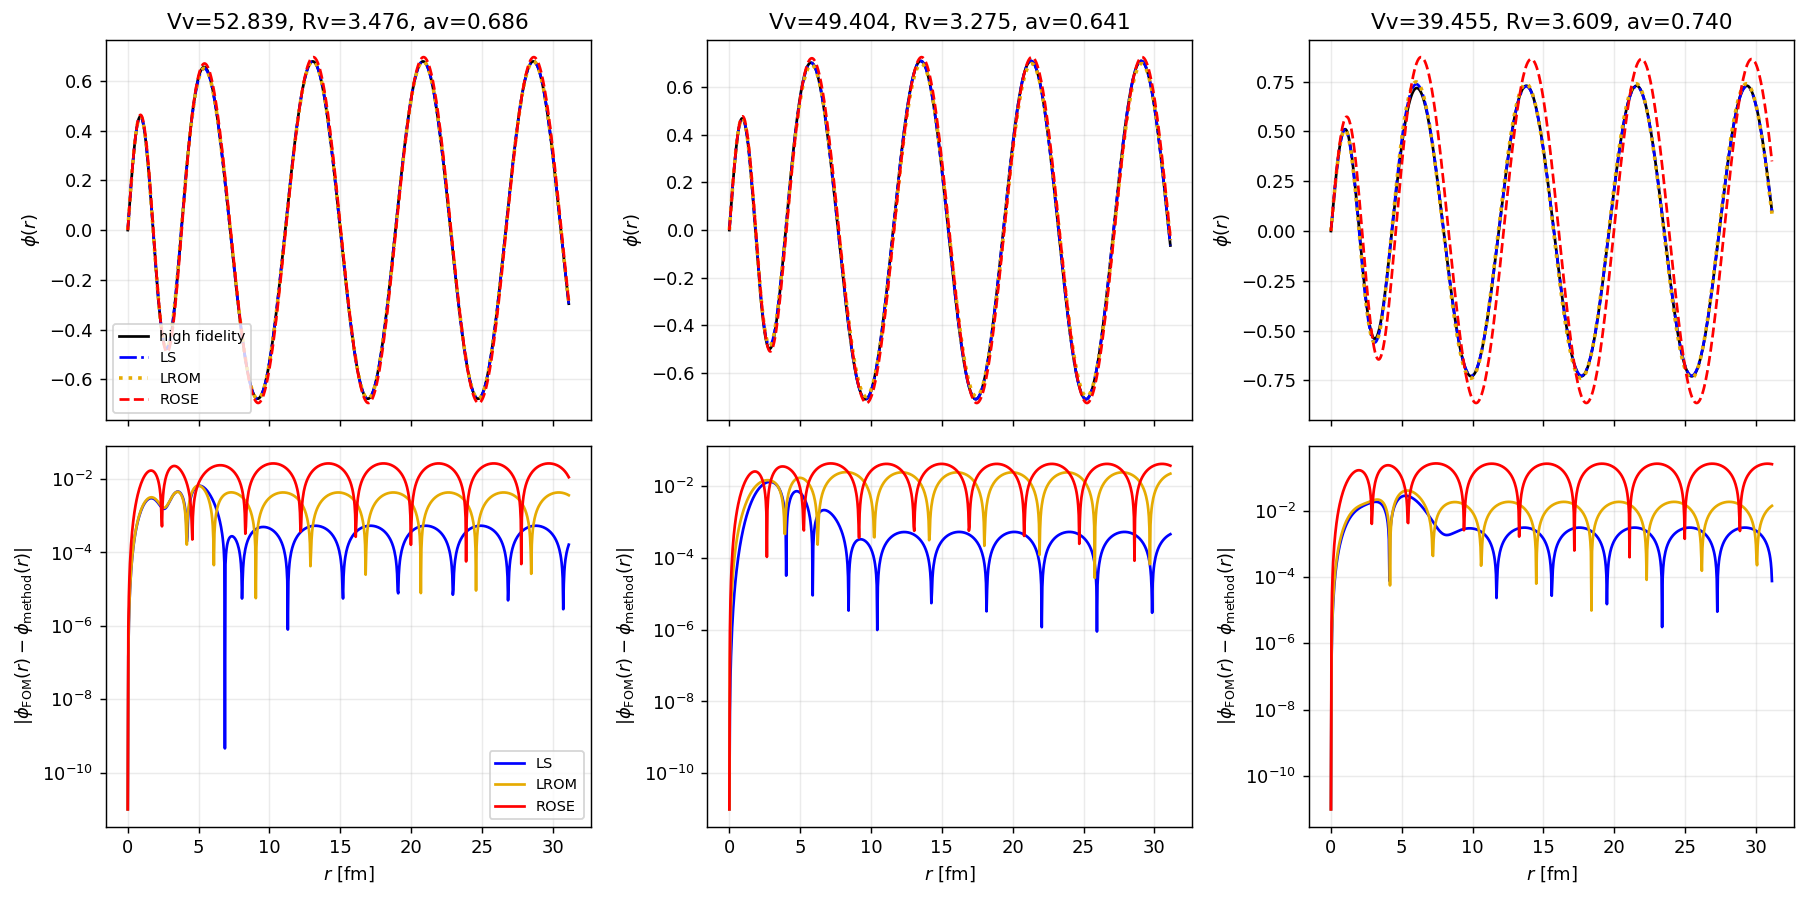

In [15]:
names = ws3_emulator.parameter_names
lo, hi = np.array([ws3_testing_ranges[n] for n in names]).T
center = np.array([ws3_center[n] for n in names])

# Distance from center, in units of each parameter's half-range.
distance = np.linalg.norm((ws3_test_rows - center) / (0.5 * (hi - lo)), axis=1)

# Test points coinciding with a training point.
in_training = (np.abs(ws3_test_rows[:, None] - ws3_train_rows).max(-1) <= 1e-12).any(1)

# Three eligible cases spread across their distance from center.
ordered = np.flatnonzero((distance >= 0.25) & ~in_training)
ordered = ordered[np.argsort(distance[ordered])]
selected = ordered[np.rint(np.array([0.25, 0.50, 0.75]) * (len(ordered) - 1)).astype(int)]
assert len(set(selected)) == 3

case_ids = np.asarray(ws3_emulator.samples.design.testing.case_ids)
ws3_selected_ids = tuple(case_ids[selected])

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col")
for col, i in enumerate(selected):
    case = ws3_emulator.testing_case(case_id=case_ids[i])
    ref = case.high_fidelity[0]
    top, bot = axes[0, col], axes[1, col]

    methods = {
        "LS":   (ws3_ls_wf_test[i],   dict(color=METHOD_COLORS["ls"],   ls="-.")),
        "LROM": (case.lrom[0],        dict(color=METHOD_COLORS["lrom"], ls=":", lw=2)),
        "ROSE": (ws3_rose_wf_test[i], dict(color=METHOD_COLORS["rose"], ls="--")),
    }
    top.plot(case.radius, ref.real, color="black", label="high fidelity")
    for label, (pred, style) in methods.items():
        top.plot(case.radius, pred.real, label=label, **style)
        bot.plot(case.radius, np.maximum(np.abs(ref - pred), DISPLAY_ERROR_FLOOR),
                 color=style["color"], label=label)

    top.set(ylabel=r"$\phi(r)$",
            title=", ".join(f"{n}={v:.3f}" for n, v in zip(names, ws3_test_rows[i])))
    bot.set(xlabel=r"$r$ [fm]", ylabel=r"$|\phi_{\mathrm{FOM}}(r)-\phi_{\mathrm{method}}(r)|$", yscale="log")

axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### Error distributions with $N_p=3$ LROM predictors

In [16]:
# Assemble raw relative-L2 metrics for matched half-violin plots.
methods = ("ls", "lrom", "rose")
colors = tuple(METHOD_COLORS[method] for method in methods)
positions = np.arange(1, 4)
training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["ls"] = ws3_ls_rel_train
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["ls"] = ws3_ls_rel_test
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.maximum(training_metrics[method], np.finfo(float).tiny)
    for method in methods
]
testing_values = [
    np.maximum(testing_metrics[method], np.finfo(float).tiny)
    for method in methods
]
training_absolute_l2 = {
    "ls": np.linalg.norm(ws3_ls_wf_train - ws3_fom_train, axis=1),
    "lrom": np.linalg.norm(ws3_emulator.training_results.lrom[0] - ws3_fom_train, axis=1),
    "rose": np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1),
}
testing_absolute_l2 = {
    "ls": np.linalg.norm(ws3_ls_wf_test - ws3_fom_test, axis=1),
    "lrom": np.linalg.norm(ws3_emulator.testing_results.lrom[0] - ws3_fom_test, axis=1),
    "rose": np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1),
}
training_absolute_values = [
    np.maximum(training_absolute_l2[method], np.finfo(float).tiny)
    for method in methods
]
testing_absolute_values = [
    np.maximum(testing_absolute_l2[method], np.finfo(float).tiny)
    for method in methods
]


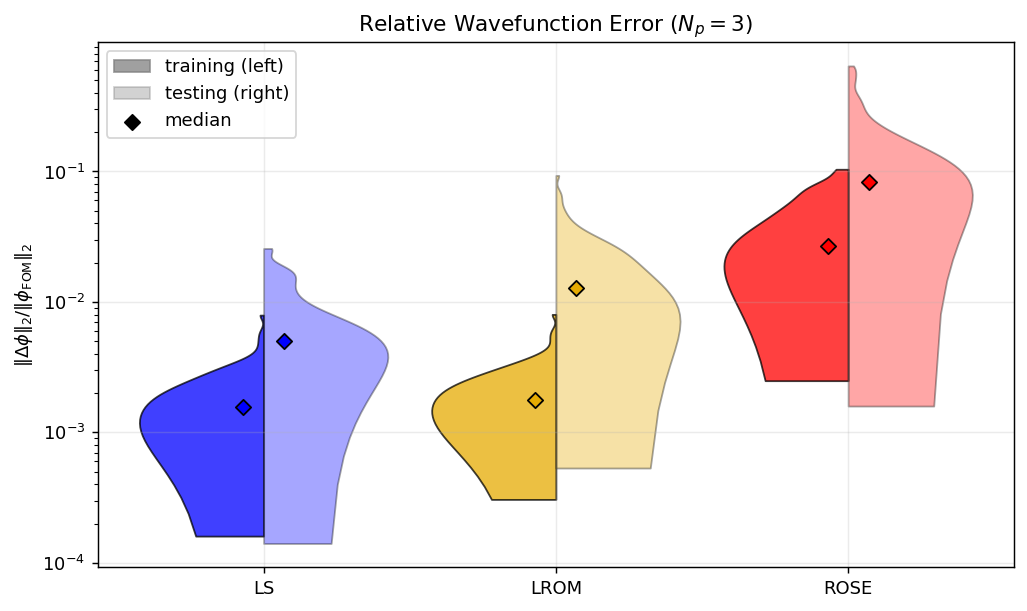

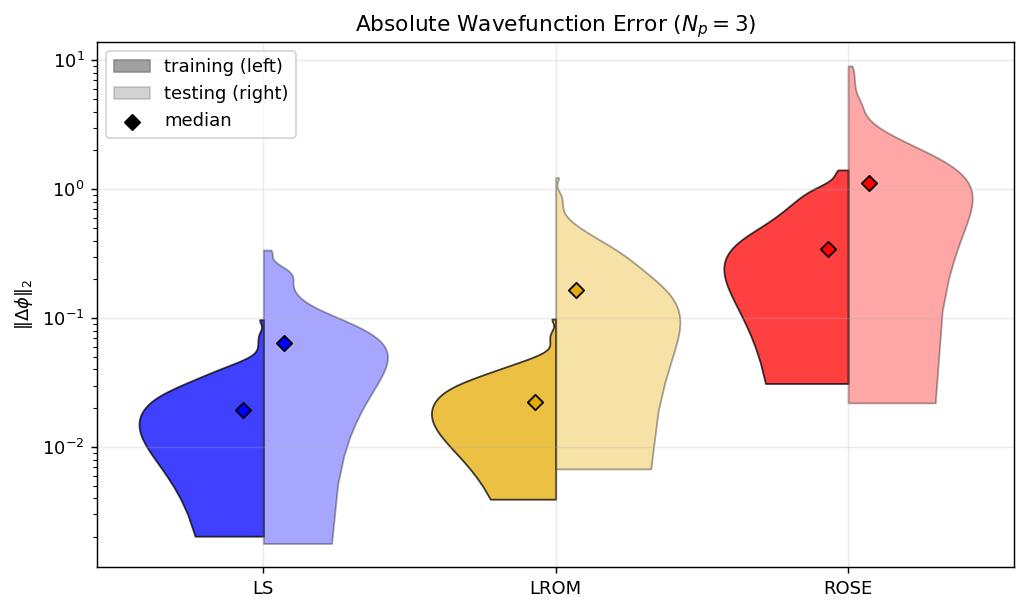

In [17]:
for training_plot_values, testing_plot_values, ylabel, title in (
    (training_values, testing_values,
     r"$\|\Delta\phi\|_2 / \|\phi_{\mathrm{FOM}}\|_2$",
     "Relative Wavefunction Error"),
    (training_absolute_values, testing_absolute_values,
     r"$\|\Delta\phi\|_2$", "Absolute Wavefunction Error"),
):
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    training_violin = ax.violinplot(
        training_plot_values, positions=positions, widths=0.85, showextrema=False
    )
    testing_violin = ax.violinplot(
        testing_plot_values, positions=positions, widths=0.85, showextrema=False
    )
    for center, body, color in zip(positions, training_violin["bodies"], colors):
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.minimum(vertices[:, 0], center)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)
    for center, body, color in zip(positions, testing_violin["bodies"], colors):
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.maximum(vertices[:, 0], center)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.35)
    for center, values, color in zip(positions, training_plot_values, colors):
        ax.scatter(center - 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
    for center, values, color in zip(positions, testing_plot_values, colors):
        ax.scatter(center + 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
    ax.set_xticks(positions, [method.upper() for method in methods])
    ax.set_yscale("log", nonpositive="clip")
    ax.set_ylabel(ylabel)
    ax.set_title(title + r" ($N_p=3$)")
    ax.fill_between([], [], color="gray", alpha=0.75, label="training (left)")
    ax.fill_between([], [], color="gray", alpha=0.35, label="testing (right)")
    ax.scatter([], [], marker="D", color="black", label="median")
    ax.legend()
    fig.tight_layout()
    plt.show()

#### Training with $N_p=6$ predictors

The performance improves with additional LROM predictors.

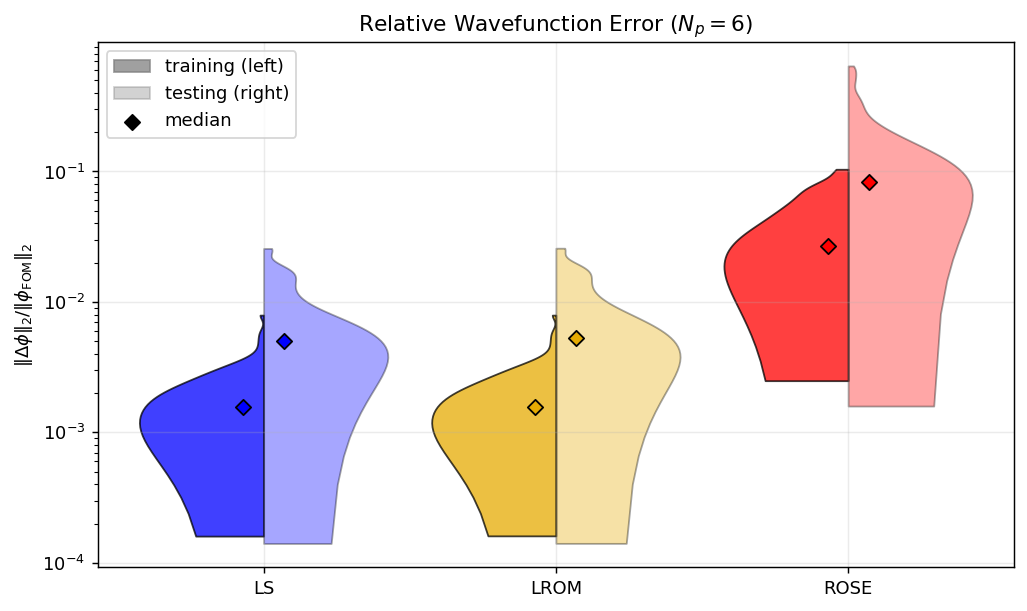

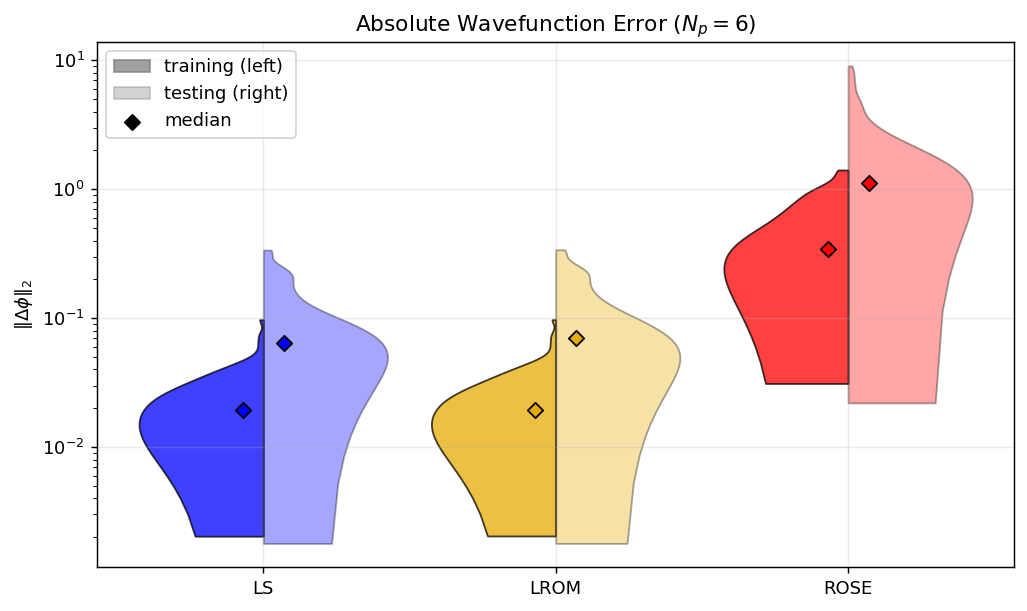

In [18]:
# retraining the emulator with 6 predictors
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=6,
)

training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["ls"] = ws3_ls_rel_train
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["ls"] = ws3_ls_rel_test
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.maximum(training_metrics[method], np.finfo(float).tiny)
    for method in methods
]
testing_values = [
    np.maximum(testing_metrics[method], np.finfo(float).tiny)
    for method in methods
]
training_absolute_l2 = {
    "ls": np.linalg.norm(ws3_ls_wf_train - ws3_fom_train, axis=1),
    "lrom": np.linalg.norm(ws3_emulator.training_results.lrom[0] - ws3_fom_train, axis=1),
    "rose": np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1),
}
testing_absolute_l2 = {
    "ls": np.linalg.norm(ws3_ls_wf_test - ws3_fom_test, axis=1),
    "lrom": np.linalg.norm(ws3_emulator.testing_results.lrom[0] - ws3_fom_test, axis=1),
    "rose": np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1),
}
training_absolute_values = [np.maximum(training_absolute_l2[method], np.finfo(float).tiny) for method in methods]
testing_absolute_values = [np.maximum(testing_absolute_l2[method], np.finfo(float).tiny) for method in methods]

for training_plot_values, testing_plot_values, ylabel, title in (
    (training_values, testing_values,
     r"$\|\Delta\phi\|_2 / \|\phi_{\mathrm{FOM}}\|_2$",
     "Relative Wavefunction Error"),
    (training_absolute_values, testing_absolute_values,
     r"$\|\Delta\phi\|_2$", "Absolute Wavefunction Error"),
):
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    training_violin = ax.violinplot(training_plot_values, positions=positions, widths=0.85, showextrema=False)
    testing_violin = ax.violinplot(testing_plot_values, positions=positions, widths=0.85, showextrema=False)
    for center, body, color in zip(positions, training_violin["bodies"], colors):
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.minimum(vertices[:, 0], center)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)
    for center, body, color in zip(positions, testing_violin["bodies"], colors):
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = np.maximum(vertices[:, 0], center)
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.35)
    for center, values, color in zip(positions, training_plot_values, colors):
        ax.scatter(center - 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
    for center, values, color in zip(positions, testing_plot_values, colors):
        ax.scatter(center + 0.07, np.median(values), marker="D", color=color, edgecolor="black", zorder=6)
    ax.set_xticks(positions, [method.upper() for method in methods])
    ax.set_yscale("log", nonpositive="clip")
    ax.set_ylabel(ylabel)
    ax.set_title(title + r" ($N_p=6$)")
    ax.fill_between([], [], color="gray", alpha=0.75, label="training (left)")
    ax.fill_between([], [], color="gray", alpha=0.35, label="testing (right)")
    ax.scatter([], [], marker="D", color="black", label="median")
    ax.legend()
    fig.tight_layout()
    plt.show()

### Saving parameters from trained emulator, along with full emulator object.

In [19]:
# Save and reload once to verify the portable model artifact and prediction path.
artifact_path = ROOT / "outputs" / "notebook01_ws3_model.lrom"
ws3_emulator.save(path=artifact_path)

portable_emulator = lrom.load(path=artifact_path)
ws3_export_case = ws3_emulator.testing_case(case_id=ws3_selected_ids[1])
portable_emulator.predict(parameters=ws3_export_case.parameters)
print("portable model:", artifact_path)
print("prediction shape:", portable_emulator.predictions.wavefunctions[0].shape)


portable model: /Users/Kitkat/Documents/Documents-Agent/LROM_Project/lrom_git/outputs/notebook01_ws3_model.lrom
prediction shape: (1, 800)
